# Løsningsforslag – øvingsoppgaver 2 – Forskningsmetode og statistiske tester
*Data Mining & Analytics – Samling 2, dag 1 (ettermiddag)*

Datasettene vi skal bruke: `tips` (restaurantregninger) og `exercise` (puls hos 30 personer under ulike aktiviteter målt etter 1, 15 og 30 minutter).
 
For hver test: formuler H₀/Hₐ, sjekk antakelser, rapporter effektstørrelse + konfidensintervall, og konkluder i tekst

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.stats.power import TTestIndPower

sns.set_theme(style="whitegrid")
rng = np.random.default_rng(1)
tips = pd.read_csv("../Data/tips.csv")
tips["tip_pct"] = tips["tip"] / tips["total_bill"] * 100
ex = pd.read_csv("../Data/exercise.csv")

def cohens_d(a, b):
    na, nb = len(a), len(b)
    sp = np.sqrt(((na - 1) * np.var(a, ddof=1) + (nb - 1) * np.var(b, ddof=1)) / (na + nb - 2))
    return (np.mean(a) - np.mean(b)) / sp

### Oppgave 1: To uavhengige grupper
Gir røykere høyere driks (i prosent) enn ikke-røykere?

- a) Formuler H₀ og Hₐ. Plott fordelingen av `tip_pct` for de to gruppene.
- b) Sjekk normalitet (Shapiro)
- c) Gjør Welch t-test og Mann–Whitney U. Beregn Cohens d og 95 % KI for differansen.
- d) Konkluder.

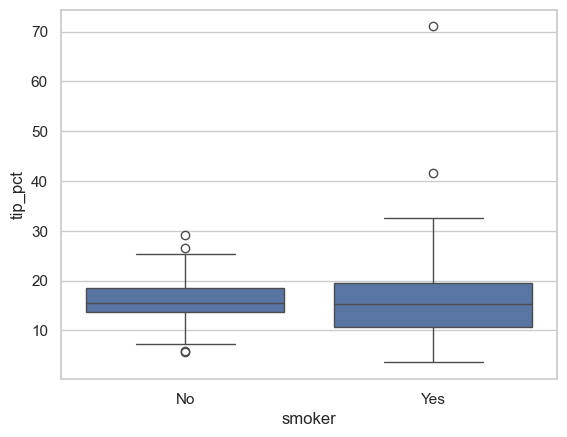

Shapiro: 0.0 0.3062   Levene: 0.0
TtestResult(statistic=np.float64(0.4112251378479481), pvalue=np.float64(0.6816579190889744), df=np.float64(117.28095240168265)) 
95 % KI for differanse: [-1.48  2.25]
Mann–Whitney: 0.561
Cohens d: 0.06    forskjell i gj.snitt: 0.39 prosentpoeng


In [2]:
a = tips.query("smoker == 'Yes'")["tip_pct"]
b = tips.query("smoker == 'No'")["tip_pct"]
sns.boxplot(data=tips, x="smoker", y="tip_pct")
plt.show()
print("Shapiro:", stats.shapiro(a).pvalue.round(4), stats.shapiro(b).pvalue.round(4), "  Levene:", stats.levene(a, b).pvalue.round(3))
res = stats.ttest_ind(a, b, equal_var=False)
print(res, "\n95 % KI for differanse:", np.round(res.confidence_interval(), 2))
print("Mann–Whitney:", stats.mannwhitneyu(a, b).pvalue.round(3))
print("Cohens d:", round(cohens_d(a, b), 2), "   forskjell i gj.snitt:", round(a.mean() - b.mean(), 2), "prosentpoeng")

**svar:**


H₀: gjennomsnittlig driks-% er lik for røykere og ikke-røykere; Hₐ: de er ulike. Antakelsene holder ikke helt: Shapiro avviser normalitet for røykerne og Levene avviser lik varians (SD 8,5 mot 4,0, drevet av noen ekstreme driks). Derfor er  Mann–Whitney riktig valg. Ingen av testene gir signifikant forskjell (p ≈ 0,6–0,7), og effekten er meget liten (d ≈ 0,06). Konfidensintervallet er ganske bredt og inkluderer 0 –> vi har ikke påvist en forskjell.

### Oppgave 2 – Paret test
Øker pulsen fra 1 til 30 minutter hos dem som løper?

- a) Lag en tabell med én rad per person for løperne (tips: pivottabell).
- b) Gjør paret t-test (og evt en Wilcoxon signed-rank test). Beregn gjennomsnittlig økning i puls med 95 % KI.
- c) Hvorfor er paret test riktigere enn uavhengig t-test her? Kjør begge (paret og uavhengig) og sammenlign p-verdiene.

In [3]:
lop = ex.query("kind == 'running'").pivot(index="id", columns="time", values="pulse")
d = lop["30 min"] - lop["1 min"]
print("Gj.snitt økning:", d.mean().round(1), " KI:", np.round(stats.t.interval(0.95, len(d) - 1, loc=d.mean(), scale=stats.sem(d)), 1))
print("Paret t:", stats.ttest_rel(lop["30 min"], lop["1 min"]))
print("Wilcoxon:", stats.wilcoxon(lop["30 min"], lop["1 min"]))
print("Uavhengig t (feil test):", stats.ttest_ind(lop["30 min"], lop["1 min"]).pvalue)

Gj.snitt økning: 29.9  KI: [18.5 41.3]
Paret t: TtestResult(statistic=np.float64(5.928967004834713), pvalue=np.float64(0.00022100433095826374), df=np.int64(9))
Wilcoxon: WilcoxonResult(statistic=np.float64(0.0), pvalue=np.float64(0.001953125))
Uavhengig t (feil test): 4.034718947143666e-05


### Oppgave 3 – Kategoriske variabler (χ²)
- a) Er ukedag (`day`) og måltid (`time`) uavhengige? Lag krysstabell, kjør `chi2_contingency`, se på forventede antall
- b) Er `smoker` og `sex` uavhengige?
- c) Hvilken test bør du bruke hvis noen av de forventede antallene er < 5?

In [4]:
for a_, b_ in [("day", "time"), ("smoker", "sex")]:
    kt = pd.crosstab(tips[a_], tips[b_])
    chi2, p, dof, exp = stats.chi2_contingency(kt)
    print(kt, f"\nχ² = {chi2:.1f}, df = {dof}, p = {p:.3g}, min forventet = {exp.min():.1f}\n")

time  Dinner  Lunch
day                
Fri       12      7
Sat       87      0
Sun       76      0
Thur       1     61 
χ² = 217.1, df = 3, p = 8.45e-47, min forventet = 5.3

sex     Female  Male
smoker              
No          54    97
Yes         33    60 
χ² = 0.0, df = 1, p = 1, min forventet = 33.2



**svar:**


Ukedag og måltid viser sterk avhengighet (torsdag gis the nesten bare tips i lunsjen, mens lørdag/søndag bare middag. `smoker` × `sex` viser ingen avhengighet (χ² ≈ 0, p ≈ 1). 
Ved forventede antall < 5 bruker vi Fisher exact (2×2) eller slår sammen kategorier og bruke Chi-square.

### Oppgave 4 – Styrke og utvalgsstørrelse
- a) Hvor mange personer trenger du per gruppe for å oppdage d = 0,3, 0,5 og 0,8 med 80 % power (α = 0,05, tosidig)?
- b) Hvilken power hadde sammenligningen røyker/ikke-røyker i oppgave 1 for å oppdage d = 0,3 (bruk gruppestørrelsene i dataene)?
- c) Hva forteller det om hvor mye vi kan stole på «ikke signifikant»-funnet?

In [5]:
pw = TTestIndPower()
for d_ in [0.3, 0.5, 0.8]:
    print(f"d = {d_}: n per gruppe = {np.ceil(pw.solve_power(d_, alpha=0.05, power=0.8)):.0f}")
n_r, n_i = (tips["smoker"] == "Yes").sum(), (tips["smoker"] == "No").sum()
print("Power for d=0.3:", round(pw.power(0.3, nobs1=n_r, ratio=n_i / n_r, alpha=0.05), 2), f"(n = {n_r} og {n_i})")

d = 0.3: n per gruppe = 176
d = 0.5: n per gruppe = 64
d = 0.8: n per gruppe = 26
Power for d=0.3: 0.62 (n = 93 og 151)


**svar:**

d = 0.3 → 176 per gruppe,
d = 0.5 → 64 per gruppe,
d = 0.8 → 26 per gruppe,

Med 93 røykere og 151 ikke-røykere er poweren for d = 0.3 bare 0.62,  dvs. en reell liten effekt kunne godt ha blitt oversett (38% sjanse). 

### Oppgave 5 – Rapportering
Skriv en «resultater»-setning (2–4 linjer, som i en artikkel) for testen i oppgave 1 og for testen i oppgave 2. Inkluder gjennomsnitt (SD), teststatistikk med frihetsgrader, p-verdi, effektstørrelse og 95 % KI.